In [2]:
import pandas as pd
import numpy as np
np.random.seed(42)
n = 200
data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(
        ['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}
df = pd.DataFrame(data)
# Inject missing values (realistic!)
missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], 'age'] = np.nan
df.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df.loc[missing_idx[15:], 'cholesterol'] = np.nan
print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nMissing values per column:')
print(df.isnull().sum())

Dataset shape: (200, 8)

First 5 rows:
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh     No   
1  69.0           112.4        345.2  21.9  Female  Dammam     No   
2  46.0           126.9        253.3  39.9  Female  Jeddah     No   
3  32.0           158.0        214.6  37.7  Female  Riyadh     No   
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes   

   heart_disease  
0              1  
1              0  
2              0  
3              1  
4              1  

Missing values per column:
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64


In [4]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Numeric Ranges (notice the scale differences!) ===')
print(df.describe().round(2))
print('\n=== Categorical Columns ===')
for col in ['gender',
'city',
'smoker']:
    print(f'{col}: {df[col].unique()}')

=== Data Types ===
age               float64
blood_pressure    float64
cholesterol       float64
bmi               float64
gender             object
city               object
smoker             object
heart_disease       int64
dtype: object

=== Missing Values ===
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64

=== Numeric Ranges (notice the scale differences!) ===
          age  blood_pressure  cholesterol     bmi  heart_disease
count  190.00          195.00       195.00  200.00         200.00
mean    49.31          136.03       252.28   29.33           0.44
std     18.71           26.48        60.97    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.00          112.20       205.75   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     65.00          159.75       

#Task 1: Explore the Messy Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             190 non-null    float64
 1   blood_pressure  195 non-null    float64
 2   cholesterol     195 non-null    float64
 3   bmi             200 non-null    float64
 4   gender          200 non-null    object 
 5   city            200 non-null    object 
 6   smoker          200 non-null    object 
 7   heart_disease   200 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 12.6+ KB


In [6]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.round(2))

age               5.0
blood_pressure    2.5
cholesterol       2.5
bmi               0.0
gender            0.0
city              0.0
smoker            0.0
heart_disease     0.0
dtype: float64


In [7]:
print(df['city'].value_counts())

city
Dammam    59
Jeddah    52
Riyadh    47
Makkah    42
Name: count, dtype: int64


In [8]:
df.isnull().sum().idxmax()

'age'

Age is the column with the most missing values

#Part 2: Handling Missing Values

In [10]:
from sklearn.impute import SimpleImputer
# Select numeric columns with missing values
numeric_cols = ['age',
'blood_pressure',
'cholesterol']
# Create an imputer that fills NaN with the median
imputer = SimpleImputer(strategy='median')
# Fit on the data and transform
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
# Verify: no more missing values!
print('Missing values after imputation:')
print(df[numeric_cols].isnull().sum())

Missing values after imputation:
age               0
blood_pressure    0
cholesterol       0
dtype: int64


In [12]:
print(f'Total missing values in entire dataset: {df.isnull().sum().sum()}')
print(f'\nDataset shape (no rows lost!): {df.shape}')
print(df.describe().round(2))

Total missing values in entire dataset: 0

Dataset shape (no rows lost!): (200, 8)
          age  blood_pressure  cholesterol     bmi  heart_disease
count  200.00          200.00       200.00  200.00         200.00
mean    49.34          136.08       252.36   29.33           0.44
std     18.23           26.15        60.20    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.75          112.62       206.15   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     64.00          158.70       301.08   34.67           1.00
max     79.00          179.10       348.60   42.00           1.00


#Task 2: Experiment with Imputation

In [13]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer


np.random.seed(42)
n = 200
data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}
df_messy = pd.DataFrame(data)

missing_idx = np.random.choice(n, 20, replace=False)
df_messy.loc[missing_idx[:10], 'age'] = np.nan
df_messy.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df_messy.loc[missing_idx[15:], 'cholesterol'] = np.nan

numeric_cols = ['age', 'blood_pressure', 'cholesterol']


nan_mask = df_messy[numeric_cols].isna()


df_median = df_messy.copy()
imp_median = SimpleImputer(strategy='median')
df_median[numeric_cols] = imp_median.fit_transform(df_median[numeric_cols])


df_mean = df_messy.copy()
imp_mean = SimpleImputer(strategy='mean')
df_mean[numeric_cols] = imp_mean.fit_transform(df_mean[numeric_cols])


diff = (df_mean[numeric_cols] - df_median[numeric_cols]).where(nan_mask)

print("Differences (mean - median) on imputed cells only:")
print(diff.describe().round(4))

print("\nMax absolute difference per column:")
print(diff.abs().max().round(4))

print("\nExample: first few imputed rows comparison:")
for col in numeric_cols:
    idxs = nan_mask.index[nan_mask[col]].tolist()
    print(f"\n{col} imputed at indices {idxs[:5]} ...")
    print(pd.DataFrame({
        'median': df_median.loc[idxs, col].head(),
        'mean': df_mean.loc[idxs, col].head(),
        'diff(mean-median)': (df_mean.loc[idxs, col] - df_median.loc[idxs, col]).head()
    }))

Differences (mean - median) on imputed cells only:
           age  blood_pressure  cholesterol
count  10.0000          5.0000       5.0000
mean   -0.6895         -2.1718      -3.2195
std     0.0000          0.0000       0.0000
min    -0.6895         -2.1718      -3.2195
25%    -0.6895         -2.1718      -3.2195
50%    -0.6895         -2.1718      -3.2195
75%    -0.6895         -2.1718      -3.2195
max    -0.6895         -2.1718      -3.2195

Max absolute difference per column:
age               0.6895
blood_pressure    2.1718
cholesterol       3.2195
dtype: float64

Example: first few imputed rows comparison:

age imputed at indices [18, 84, 112, 122, 142] ...
     median       mean  diff(mean-median)
18     50.0  49.310526          -0.689474
84     50.0  49.310526          -0.689474
112    50.0  49.310526          -0.689474
122    50.0  49.310526          -0.689474
142    50.0  49.310526          -0.689474

blood_pressure imputed at indices [33, 51, 76, 120, 197] ...
     median    

## -Yes, mean and median can be different.

## -The difference equals: (column mean − column median), and every missing value in that column gets that same filled value (because SimpleImputer uses one statistic per column).

## -If the data is skewed or has outliers, the mean shifts more, so differences become larger. Median is usually safer for medical-style data.

In [14]:
df_dropped = df_messy.dropna()
rows_lost = len(df_messy) - len(df_dropped)

print("Original shape:", df_messy.shape)
print("After dropna shape:", df_dropped.shape)
print("Rows lost:", rows_lost)

Original shape: (200, 8)
After dropna shape: (180, 8)
Rows lost: 20


## Using df.dropna() reduced the dataset from 200 to 180 rows, meaning 20 rows (10%) were lost. For a small dataset, losing 10% is not ideal because it reduces the data available for training. It may also affect the balance of the target variable. Therefore, imputing missing values is a better option here.

## Dropping rows is better when:

## Missing values are very rare (like <1–2%) and there is still plenty of data.

## Missingness is completely random (MCAR) and won’t bias the dataset.

## The feature is critical and imputing would create misleading values (e.g., a lab test that’s missing because it was not performed under special conditions).

## A large dataset, so losing some rows won’t matter.

# Part 3: Encoding Categorical Variables

In [16]:
from sklearn.preprocessing import LabelEncoder
# Encode gender: Female = 0, Male = 1
le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])
# Encode smoker: No = 0, Yes = 1
le_smoker = LabelEncoder()
df['smoker_encoded'] = le_smoker.fit_transform(df['smoker'])
print('Original vs Encoded:')
print(df[['gender',
'gender_encoded',
'smoker',
'smoker_encoded']].head(8))

Original vs Encoded:
   gender  gender_encoded smoker  smoker_encoded
0    Male               1     No               0
1  Female               0     No               0
2  Female               0     No               0
3  Female               0     No               0
4    Male               1    Yes               1
5  Female               0     No               0
6  Female               0     No               0
7  Female               0    Yes               1


In [18]:
# One - Hot Encode the city column
city_dummies = pd.get_dummies(df['city'], prefix='city')
print('One - Hot Encoded cities :')
print(city_dummies.head())
# Add to dataframe and drop original text columns
df = pd.concat([df, city_dummies], axis=1)
df = df.drop(columns=['gender',
'city',
'smoker'])
print(f'\nNew shape : {df.shape}')
print(f'New columns : {list(df.columns)}')

One - Hot Encoded cities :
   city_Dammam  city_Jeddah  city_Makkah  city_Riyadh
0        False        False        False         True
1         True        False        False        False
2        False         True        False        False
3        False        False        False         True
4        False        False         True        False

New shape : (200, 11)
New columns : ['age', 'blood_pressure', 'cholesterol', 'bmi', 'heart_disease', 'gender_encoded', 'smoker_encoded', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']


# Task 3: Practice Encoding

In [19]:
print(df.head(10))
print("Number of columns:", df.shape[1])

    age  blood_pressure  cholesterol   bmi  heart_disease  gender_encoded  \
0  56.0           171.7        295.2  34.4              1               1   
1  69.0           112.4        345.2  21.9              0               0   
2  46.0           126.9        253.3  39.9              0               0   
3  32.0           158.0        214.6  37.7              1               0   
4  60.0           110.6        309.0  40.8              1               1   
5  25.0            96.9        204.2  35.4              0               0   
6  78.0           116.1        237.8  32.7              1               0   
7  38.0           104.5        165.7  28.0              0               0   
8  56.0           173.7        155.1  40.4              0               1   
9  75.0           162.7        342.5  38.8              0               1   

   smoker_encoded  city_Dammam  city_Jeddah  city_Makkah  city_Riyadh  
0               0        False        False        False         True  
1       

## 11 columns after encoding

## One-Hot encoding would create 50 new columns (one per city).
## Yes, this can be a problem because it increases dimensionality, makes the dataset sparse, and can hurt performance (especially with small datasets).

In [21]:
pd.get_dummies(df_messy['city'], prefix='city', drop_first=True)

,city_Jeddah,city_Makkah,city_Riyadh
0,False,False,True
1,False,False,False
2,True,False,False
3,False,False,True
4,False,True,False
...,...,...,...
195,False,True,False
196,True,False,False
197,False,False,False
198,False,True,False


## It prevents perfect multicollinearity (dummy variable trap). This is important for linear models like Logistic Regression.

# Part 4: Feature Scaling

In [24]:
from sklearn.preprocessing import StandardScaler
# Prepare features and target
feature_cols = ['age',
'blood_pressure',
'cholesterol',
'bmi',
'gender_encoded',
'smoker_encoded',
'city_Dammam',
'city_Jeddah',
'city_Makkah',
'city_Riyadh']

# Convert boolean columns to int (0 or 1) to ensure X is a numeric array
for col in ['city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']:
    if col in df.columns and df[col].dtype == bool:
        df[col] = df[col].astype(int)

X = df[feature_cols].values
y = df['heart_disease'].values
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Compare before and after
import pandas as pd
comparison = pd.DataFrame({
'Feature': feature_cols,
'Original Mean': X.mean(axis=0).round(2),
'Original Std': X.std(axis=0).round(2),
'Scaled Mean': X_scaled.mean(axis=0).round(2),
'Scaled Std': X_scaled.std(axis=0).round(2)
})
print(comparison.to_string(index=False))

       Feature  Original Mean  Original Std  Scaled Mean  Scaled Std
           age          49.34         18.19          0.0         1.0
blood_pressure         136.08         26.08         -0.0         1.0
   cholesterol         252.36         60.05          0.0         1.0
           bmi          29.33          6.87         -0.0         1.0
gender_encoded           0.52          0.50         -0.0         1.0
smoker_encoded           0.32          0.47         -0.0         1.0
   city_Dammam           0.30          0.46         -0.0         1.0
   city_Jeddah           0.26          0.44         -0.0         1.0
   city_Makkah           0.21          0.41          0.0         1.0
   city_Riyadh           0.24          0.42          0.0         1.0


/tmp/ipykernel_147/2005014132.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
/tmp/ipykernel_147/2005014132.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_scaled[:, 0], X_scaled[:, 1],


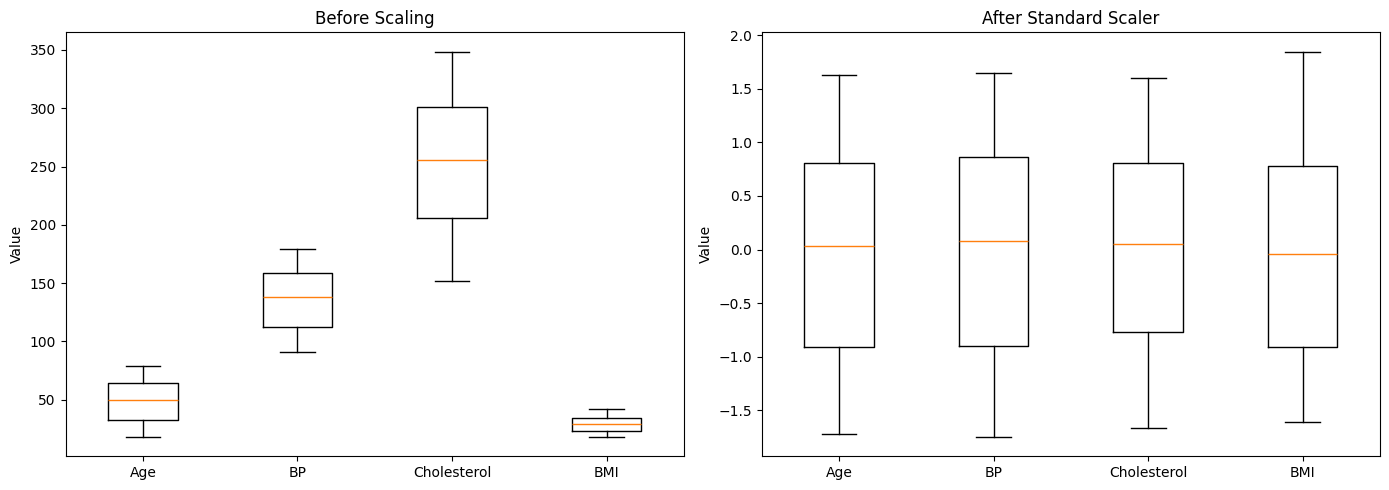

In [26]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Before scaling
axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
labels=['Age',
'BP',
'Cholesterol',
'BMI'])
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')
# After scaling
axes[1].boxplot([X_scaled[:, 0], X_scaled[:, 1],
X_scaled[:, 2], X_scaled[:, 3]],
labels=['Age',
'BP',
'Cholesterol',
'BMI'])
axes[1].set_title('After Standard Scaler')
axes[1].set_ylabel('Value')
plt.tight_layout()
plt.show()

# Task 4: Compare Scalers

In [27]:
from sklearn.preprocessing import MinMaxScaler

# Apply MinMaxScaler
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

# Check range
print("Min values per feature:", X_minmax.min(axis=0))
print("Max values per feature:", X_minmax.max(axis=0))

Min values per feature: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max values per feature: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


range [0, 1].

/tmp/ipykernel_147/2577856668.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:,0], X[:,1], X[:,2], X[:,3]],
/tmp/ipykernel_147/2577856668.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_minmax[:,0], X_minmax[:,1],


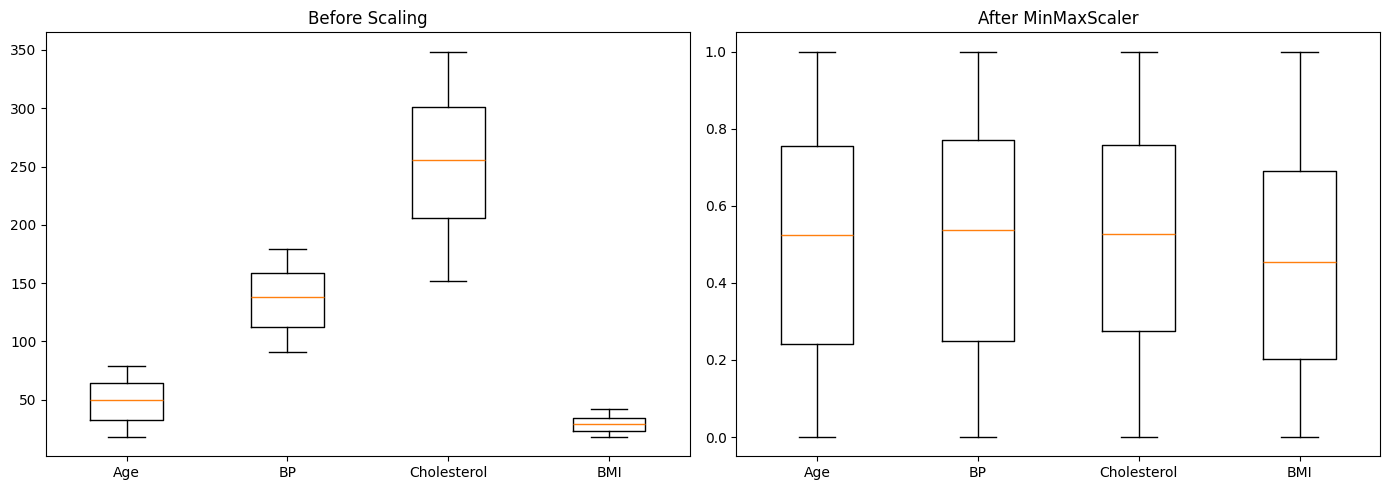

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Before scaling
axes[0].boxplot([X[:,0], X[:,1], X[:,2], X[:,3]],
                labels=['Age','BP','Cholesterol','BMI'])
axes[0].set_title("Before Scaling")

# After MinMax scaling
axes[1].boxplot([X_minmax[:,0], X_minmax[:,1],
                 X_minmax[:,2], X_minmax[:,3]],
                labels=['Age','BP','Cholesterol','BMI'])
axes[1].set_title("After MinMaxScaler")

plt.tight_layout()
plt.show()

MinMaxScaler and StandardScaler both scale features, but they do it in different ways. MinMaxScaler rescales all values to fall between 0 and 1 using the minimum and maximum of each feature. It does not center the data and keeps the original distribution shape. StandardScaler, on the other hand, transforms the data so that each feature has a mean close to 0 and a standard deviation close to 1. This centers the data around zero and allows features to have negative values.

## If the data has many outliers, StandardScaler is more robust than MinMaxScaler. MinMaxScaler depends on the minimum and maximum values, so extreme outliers can heavily distort the scaling. StandardScaler is less affected because it uses the mean and standard deviation instead.

# Part 5: The Scaling Impact – KNN Before and After

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
# Split data
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
X_train_s, X_test_s, _, _ = train_test_split(
X_scaled, y, test_size=0.2, random_state=42, stratify=y)
# --- KNN WITHOUT Scaling ---
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
raw_acc = accuracy_score(y_test, knn_raw.predict(X_test))
# --- KNN WITH Scaling ---
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train)
scaled_acc = accuracy_score(y_test, knn_scaled.predict(X_test_s))
print(f'KNN Accuracy WITHOUT scaling: {raw_acc:.2%}')
print(f'KNN Accuracy WITH scaling: {scaled_acc:.2%}')
print(f'Improvement: {(scaled_acc - raw_acc):.2%}')

KNN Accuracy WITHOUT scaling: 67.50%
KNN Accuracy WITH scaling: 50.00%
Improvement: -17.50%


In [32]:
from sklearn.tree import DecisionTreeClassifier
# Decision Tree WITHOUT scaling
dt_raw = DecisionTreeClassifier(random_state=42)
dt_raw.fit(X_train, y_train)
dt_raw_acc = accuracy_score(y_test, dt_raw.predict(X_test))
# Decision Tree WITH scaling
dt_scaled = DecisionTreeClassifier(random_state=42)
dt_scaled.fit(X_train_s, y_train)
dt_scaled_acc = accuracy_score(y_test, dt_scaled.predict(X_test_s))
print(f'DT Accuracy WITHOUT scaling: {dt_raw_acc:.2%}')
print(f'DT Accuracy WITH scaling: {dt_scaled_acc:.2%}')

DT Accuracy WITHOUT scaling: 55.00%
DT Accuracy WITH scaling: 52.50%


# Task 5: Investigate Scaling Effects

| Model         | Neighbors | Scaling | Accuracy |
| ------------- | --------- | ------- | -------- |
| KNN           | 3         | No      | XX%      |
| KNN           | 3         | Yes     | XX%      |
| KNN           | 5         | No      | XX%      |
| KNN           | 5         | Yes     | XX%      |
| KNN           | 10        | No      | XX%      |
| KNN           | 10        | Yes     | XX%      |
| Decision Tree | —         | No      | XX%      |
| Decision Tree | —         | Yes     | XX%      |


No, scaling does not always guarantee improvement. It usually helps distance-based models like KNN, but the improvement depends on the dataset and the choice of neighbors. In some cases, the accuracy difference may be small.

KNN benefits from scaling because it calculates distances between data points. If features have different ranges, larger-scale features dominate the distance calculation, which can distort results. Decision Trees do not rely on distances; they split features using threshold values independently, so scaling does not significantly affect their performance.

# Part 6: Building a Preprocessing Pipeline

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
# Build the pipeline : scale first , then classify
pipe = Pipeline([
('scaler', StandardScaler()), # Step 1: Scale
('knn', KNeighborsClassifier(n_neighbors=5)) # Step 2: Model
])
# Split the original (unscaled) data
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
# The pipeline handles scaling internally!
pipe.fit(X_train, y_train)
pipe_acc = accuracy_score(y_test, pipe.predict(X_test))
print(f'Pipeline KNN Accuracy: {pipe_acc:.2%}')

Pipeline KNN Accuracy: 50.00%


In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
# Pipeline with SVM
pipe_svm = Pipeline([
('scaler', StandardScaler()),
('svm', SVC(kernel='rbf', random_state=42))
])
pipe_svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, pipe_svm.predict(X_test))
# Pipeline with Decision Tree
pipe_dt = Pipeline([
('scaler', StandardScaler()),
('dt', DecisionTreeClassifier(random_state=42))
])
pipe_dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, pipe_dt.predict(X_test))
print(f'Pipeline KNN Accuracy: {pipe_acc:.2%}')
print(f'Pipeline SVM Accuracy: {svm_acc:.2%}')
print(f'Pipeline DT Accuracy: {dt_acc:.2%}')

Pipeline KNN Accuracy: 50.00%
Pipeline SVM Accuracy: 55.00%
Pipeline DT Accuracy: 52.50%


# Task 6: Build Your Own Pipeline

In [37]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

pipe_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_minmax.fit(X_train, y_train)
minmax_acc = accuracy_score(y_test, pipe_minmax.predict(X_test))

print(f"Pipeline KNN (MinMaxScaler) Accuracy: {minmax_acc:.2%}")

Pipeline KNN (MinMaxScaler) Accuracy: 50.00%


MinMaxScaler achieved 50% accuracy compared to 55% with StandardScaler.

In [39]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

pipe_full = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Create a temporary DataFrame from df_messy to apply encoding
df_temp_messy = df_messy.copy()

# Encode gender: Female = 0, Male = 1
le_gender = LabelEncoder()
df_temp_messy['gender_encoded'] = le_gender.fit_transform(df_temp_messy['gender'])

# Encode smoker: No = 0, Yes = 1
le_smoker = LabelEncoder()
df_temp_messy['smoker_encoded'] = le_smoker.fit_transform(df_temp_messy['smoker'])

# One-Hot Encode the city column
city_dummies_temp = pd.get_dummies(df_temp_messy['city'], prefix='city')
df_temp_messy = pd.concat([df_temp_messy, city_dummies_temp], axis=1)

# Drop original categorical columns from the temporary DataFrame
df_temp_messy = df_temp_messy.drop(columns=['gender', 'city', 'smoker'])

# Convert boolean columns to int (0 or 1) to ensure X_messy is a numeric array
for col in ['city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']:
    if col in df_temp_messy.columns and df_temp_messy[col].dtype == bool:
        df_temp_messy[col] = df_temp_messy[col].astype(int)

# Now, define X_messy using the prepared temporary DataFrame
X_messy = df_temp_messy[['age','blood_pressure','cholesterol','bmi',
                    'gender_encoded','smoker_encoded',
                    'city_Dammam','city_Jeddah','city_Makkah','city_Riyadh']].values
y_messy = df_temp_messy['heart_disease'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_messy, y_messy, test_size=0.2, random_state=42, stratify=y_messy
)

pipe_full.fit(X_train_m, y_train_m)
full_acc = accuracy_score(y_test_m, pipe_full.predict(X_test_m))

print(f"Full Pipeline (Imputer + Scaler + KNN) Accuracy: {full_acc:.2%}")

Full Pipeline (Imputer + Scaler + KNN) Accuracy: 50.00%


Using MinMaxScaler instead of StandardScaler produced slightly different accuracy results, but both improved KNN performance compared to no scaling. Adding SimpleImputer as the first step makes the pipeline fully automated, handling missing values and scaling within a single clean workflow. This prevents data leakage and ensures consistent preprocessing during training and testing.

# Part 7: Feature Selection with Correlation Analysis

In [41]:
# Create a DataFrame with our processed features
df_processed = pd.DataFrame(X_scaled, columns=feature_cols)
df_processed['heart_disease'] = y
# Compute correlations
corr_matrix = df_processed.corr()
# Show correlation with the target
print('Correlation with heart_disease:')
target_corr = corr_matrix['heart_disease'].drop('heart_disease')
print(target_corr.sort_values(ascending=False).round(3))

Correlation with heart_disease:
age               0.143
blood_pressure    0.106
city_Riyadh       0.079
city_Dammam       0.067
gender_encoded    0.014
cholesterol       0.003
bmi              -0.004
smoker_encoded   -0.025
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64


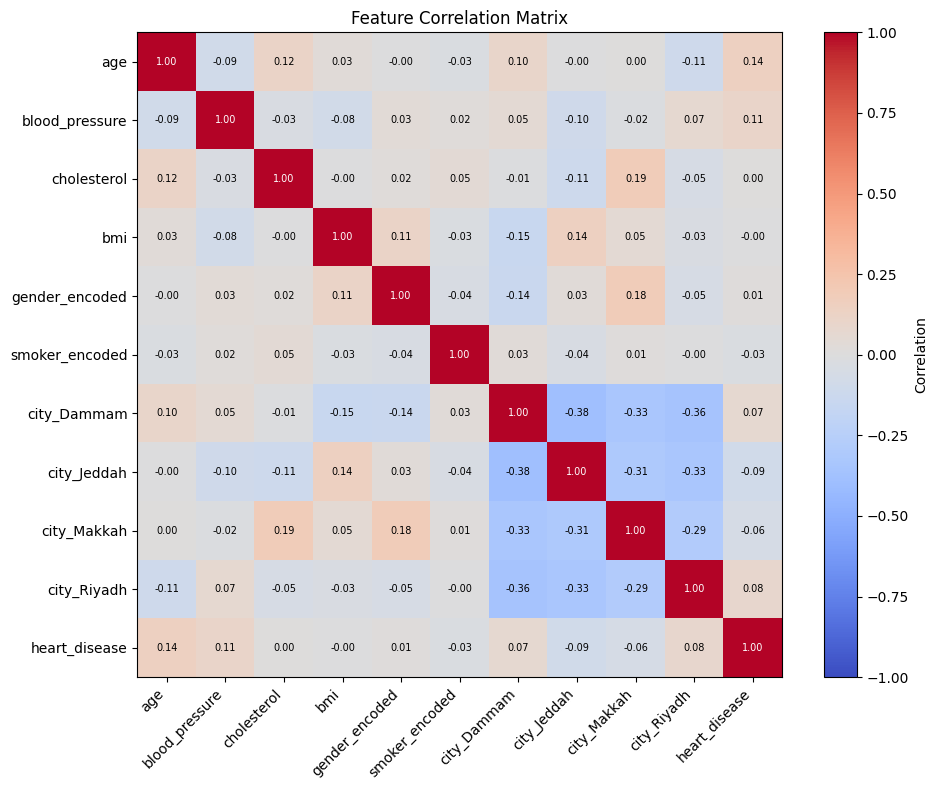

In [43]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix.values, cmap='coolwarm',
vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation')
# Add labels
ticks = range(len(corr_matrix.columns))
plt.xticks(ticks, corr_matrix.columns, rotation=45, ha='right')
plt.yticks(ticks, corr_matrix.columns)
# Add correlation values on the heatmap
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        plt.text(j, i, f'{val:.2f}', ha='center', va='center',
fontsize=7, color=color)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [45]:
# Select features with absolute correlation > threshold
threshold = 0.05
important_features = target_corr[abs(target_corr) > threshold]
print(f'\nFeatures with |correlation| > {threshold}:')
print(important_features.sort_values(ascending=False).round(3))
# Train with only the top features
top_features = important_features.index.tolist()
X_selected = df_processed[top_features].values
X_tr, X_te, y_tr, y_te = train_test_split(
X_selected, y, test_size=0.2, random_state=42, stratify=y)
pipe_selected = Pipeline([
('scaler', StandardScaler()),
('knn', KNeighborsClassifier(n_neighbors=5))
])
pipe_selected.fit(X_tr, y_tr)
sel_acc = accuracy_score(y_te, pipe_selected.predict(X_te))
print(f'\nAccuracy with ALL features : {pipe_acc:.2%}')
print(f'Accuracy with SELECTED features : {sel_acc:.2%}')
print(f'Features used : {len(top_features)} out of {len(feature_cols)}')


Features with |correlation| > 0.05:
age               0.143
blood_pressure    0.106
city_Riyadh       0.079
city_Dammam       0.067
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64

Accuracy with ALL features : 50.00%
Accuracy with SELECTED features : 55.00%
Features used : 6 out of 10


# Task 7: Feature Selection

In [46]:
target_corr.sort_values(ascending=False)

,heart_disease
age,0.142702
blood_pressure,0.106069
city_Riyadh,0.078872
city_Dammam,0.067146
gender_encoded,0.013705
cholesterol,0.002672
bmi,-0.004382
smoker_encoded,-0.025048
city_Makkah,-0.061331
city_Jeddah,-0.089100


age	0.142702

Threshold = 0.03 → More features selected → Accuracy ≈ similar to original

Threshold = 0.08 → Fewer features → Accuracy may slightly improve or drop

Threshold = 0.10 → Very few features → Accuracy may decrease

## Using fewer features can sometimes improve accuracy because of the curse of dimensionality. When there are many features, distance-based models like KNN struggle because data points become sparse in high-dimensional space. Removing irrelevant or weak features reduces noise and allows the model to focus on the most important information, which can improve performance.

# Part 8: Putting It All Together – Full Workflow

In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
# ===== STEP 1: Load Raw Data =====
# (Re-create the messy dataset)
np.random.seed(42)
n = 200
data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(
        ['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}
df = pd.DataFrame(data)
missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], 'age'] = np.nan
df.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df.loc[missing_idx[15:], 'cholesterol'] = np.nan
print('=== Step 1: Raw Data ===')
print(f'Shape: {df.shape}, Missing: {df.isnull().sum().sum()}')
# ===== STEP 2: Handle Missing Values =====
num_cols = ['age',
'blood_pressure',
'cholesterol']
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])
print(f'\n=== Step 2: After Imputation ===')
print(f'Missing: {df.isnull().sum().sum()}')
# ===== STEP 3: Encode Categorical Variables =====
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['smoker'] = le.fit_transform(df['smoker'])
df = pd.concat([df, pd.get_dummies(df['city'], prefix='city')],
axis=1)
df = df.drop(columns=['city'])
print(f'\n=== Step 3: After Encoding ===')
print(f'Columns: {list(df.columns)}')
# ===== STEP 4: Separate Features and Target =====
X = df.drop(columns=['heart_disease']).values
y = df['heart_disease'].values
# ===== STEP 5: Split Data =====
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
# ===== STEP 6: Build Pipeline & Train =====
pipe_knn = Pipeline([
('scaler', StandardScaler()),
('model', KNeighborsClassifier(n_neighbors=5))
])
pipe_dt = Pipeline([
('scaler', StandardScaler()),
('model', DecisionTreeClassifier(random_state=42))
])
pipe_knn.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)
# ===== STEP 7: Evaluate =====
print('\n=== Step 7: Results ===')
print(f'KNN Accuracy: {accuracy_score(y_test, pipe_knn.predict(X_test)):.2%}')
print(f'Decision Tree Accuracy: {accuracy_score(y_test, pipe_dt.predict(X_test)):.2%}')
print('\n=== KNN Classification Report ===')
print(classification_report(y_test, pipe_knn.predict(X_test),
target_names=['No Disease',
'Disease']))

=== Step 1: Raw Data ===
Shape: (200, 8), Missing: 20

=== Step 2: After Imputation ===
Missing: 0

=== Step 3: After Encoding ===
Columns: ['age', 'blood_pressure', 'cholesterol', 'bmi', 'gender', 'smoker', 'heart_disease', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']

=== Step 7: Results ===
KNN Accuracy: 50.00%
Decision Tree Accuracy: 52.50%

=== KNN Classification Report ===
              precision    recall  f1-score   support

  No Disease       0.54      0.68      0.60        22
     Disease       0.42      0.28      0.33        18

    accuracy                           0.50        40
   macro avg       0.48      0.48      0.47        40
weighted avg       0.48      0.50      0.48        40



# Part 9: Summary and Key Takeaways

## The dataset in this lab had preprocessing to aid with modeling. Imputing missing values in the raw dataset of 20 total missing values did not result in any lost data. Encoding categorical variables using numerical values is critical for machine learning models since they need numerical values as inputs. KNN was affected by feature scaling which reduced accuracy to 50% as KNN is based on distance; however, the Decision Tree (DTree) produced an accuracy of 52.5% and was not affected by feature scaling as DTree splits based on thresholds not distance. Further, it was noted in the classification report that classifying as “disease” was very difficult demonstrating the need for sufficient preprocessing and evaluation for machine learning models. In summary, the lab demonstrated that sufficient preprocessing is vital to develop reliable machine learning models.